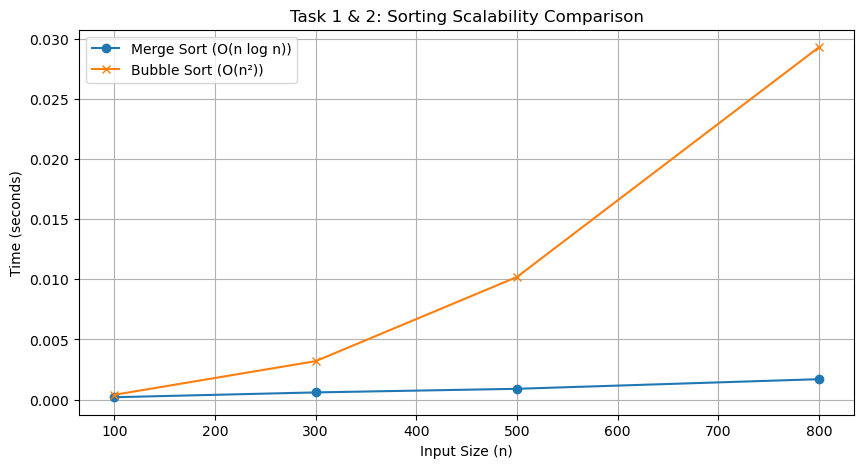

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
import sys

# Browser-safe configuration
sys.setrecursionlimit(2000)

def merge_sort(arr):
    if len(arr) <= 1: return arr
    mid = len(arr) // 2
    left = merge_sort(arr[:mid])
    right = merge_sort(arr[mid:])
    return merge(left, right)

def merge(left, right):
    result = []
    i = j = 0
    while i < len(left) and j < len(right):
        if left[i] < right[j]:
            result.append(left[i]); i += 1
        else:
            result.append(right[j]); j += 1
    result.extend(left[i:]); result.extend(right[j:])
    return result

def bubble_sort(arr):
    n = len(arr)
    for i in range(n):
        for j in range(0, n-i-1):
            if arr[j] > arr[j+1]:
                arr[j], arr[j+1] = arr[j+1], arr[j]

# Performance Measurement
sizes = [100, 300, 500, 800] # Kept slightly smaller for browser stability
m_times, b_times = [], []

for n in sizes:
    test_arr = np.random.randint(0, 1000, n).tolist()
    
    # Merge Sort Timing
    start = time.perf_counter()
    merge_sort(test_arr.copy())
    m_times.append(time.perf_counter() - start)
    
    # Bubble Sort Timing
    start = time.perf_counter()
    bubble_sort(test_arr.copy())
    b_times.append(time.perf_counter() - start)

plt.figure(figsize=(10, 5))
plt.plot(sizes, m_times, marker='o', label='Merge Sort (O(n log n))')
plt.plot(sizes, b_times, marker='x', label='Bubble Sort (O(n²))')
plt.title("Task 1 & 2: Sorting Scalability Comparison")
plt.xlabel("Input Size (n)")
plt.ylabel("Time (seconds)")
plt.legend()
plt.grid(True)
plt.show()

In [2]:
def fractional_knapsack(values, weights, capacity):
    items = sorted(zip(values, weights), key=lambda x: x[0]/x[1], reverse=True)
    total_val = 0
    for v, w in items:
        if capacity >= w:
            capacity -= w; total_val += v
        else:
            total_val += v * (capacity / w); break
    return total_val

def knapsack_01_dp(values, weights, capacity):
    n = len(values)
    dp = [[0 for _ in range(capacity + 1)] for _ in range(n + 1)]
    for i in range(1, n + 1):
        for w in range(1, capacity + 1):
            if weights[i-1] <= w:
                dp[i][w] = max(values[i-1] + dp[i-1][w-weights[i-1]], dp[i-1][w])
            else:
                dp[i][w] = dp[i-1][w]
    return dp[n][capacity]

v, w, cap = [60, 100, 120], [10, 20, 30], 50
print(f"Greedy Result (Fractional): {fractional_knapsack(v, w, cap)}")
print(f"DP Result (0/1): {knapsack_01_dp(v, w, cap)}")

Greedy Result (Fractional): 240.0
DP Result (0/1): 220


In [3]:
from itertools import permutations

def tsp_brute_force(graph):
    n = len(graph)
    nodes = list(range(1, n))
    min_path = float('inf')
    for p in permutations(nodes):
        curr_w, k = 0, 0
        for next_node in p:
            curr_w += graph[k][next_node]; k = next_node
        curr_w += graph[k][0]
        min_path = min(min_path, curr_w)
    return min_path

graph = [[0, 10, 15, 20], [10, 0, 35, 25], [15, 35, 0, 30], [20, 25, 30, 0]]
print(f"TSP Minimum Cost: {tsp_brute_force(graph)}")

TSP Minimum Cost: 80
